# Zadanie 1: optymalizacja gradientowa

Termin realizacji: 16 marca 2026

Wybierz jedną z testowych funkcji o dwóch zmiennych do optymalizacji (z [https://en.wikipedia.org/wiki/Test_functions_for_optimization](Test_functions_for_optimization)) (oprócz "sphere function", "Matyas function" i "Booth function").

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Weź implementację optymalizacji gradientowej z zadania z ostatnich ćwiczeń. Zwróć uwagę na:
   1. Punkt powinien być reprezentowany jako tablica (np. `Vector`), a nie jako pojedyncze zmienne.
   2. Funkcja optymalizowana powinna być funkcją, która przyjmuje wektor i zwraca liczbę rzeczywistą.
   3. Gradient powinien być wektorem o tym samym wymierze co punkt.
2. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
3. Przeprowadź procedurę dla kilku kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

Możesz skorzystać z kodu pod zadaniem na 5.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień stały krok z poprzedniego zadania na warunek wystarczającego spadku Armijo. Jako początkowy bracket przyjmij $[0, 1]$. Porównaj zbieżność metody o stałym kroku z przeszukiwaniem liniowym za pomocą wykresów wartości w konkretnym kroku uśrednione między poszczególnymi punktami początkowymi. Porównaj wyniki dla 6 różnych kombinacji parametrów metody Armijo.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zamień stały bracket $[0, 1]$ z poprzedniego punktu na metodę automatycznie określającą bracket (przykład z wykładu). Porównaj wyniki z poprzednią metodą dla minimum 6 zestawów parametrów bracketingu.


In [24]:
# using LinearAlgebra
# using Plots
# using Random

# contourf(x, y, z, fill=true, color=:plasma)

# Zadania na 3.0:

## Funkcja: Three-hump camel function
$f(x,y)=2x^{2}-1.05x^{4}+{\frac {x^{6}}{6}}+xy+y^{2}$

Ma globalne minimum w punkcie $(0, 0)$ z wartością $f(0,0) = 0$.

In [25]:
function f(x::Vector)
    return 2*x[1]^2 - 1.05*x[1]^4 + x[1]^6/6 + x[1]*x[2] + x[2]^2
end

# Gradient funkcji
function grad_f!(g::Vector, x::Vector)
    g[1] = 4*x[1] - 4.2*x[1]^3 + x[1]^5 + x[2]
    g[2] = x[1] + 2*x[2]
end

# Dziedzina: [-5, 5] x [-5, 5]
const DOMAIN = (-5.0, 5.0)

(-5.0, 5.0)

In [26]:
println("f(1.0, 1.0) = ", f([1.0, 1.0]))
println("grad_f(1.0, 1.0) = ", grad_f!([0.0, 0.0], [1.0, 1.0]))

println("f(0.0, 0.0) = ", f([0.0, 0.0]))
println("grad_f(0.0, 0.0) = ", grad_f!([0.0, 0.0], [0.0, 0.0]))

f(1.0, 1.0) = 3.1166666666666667
grad_f(1.0, 1.0) = 3.0
f(0.0, 0.0) = 0.0
grad_f(0.0, 0.0) = 0.0


## Optymalizacja gradientowa

In [27]:
function my_optimize_const_step(cost_data, grad_data, x0;
        step=1e-5, maxiter=100000, tol=1e-6)

    x = copy(x0)
    g = similar(x)

    fx = cost_data(x)
    if !isfinite(fx)
        error("cost_data(x0) is not finite (got $fx). Choose a valid x0 / fix cost domain.")
    end

    for k in 1:maxiter
        grad_data(g, x)
        if any(!isfinite, g)
            error("Gradient became non-finite at iter=$k")
        end

        if norm(g) < tol
            return x
        end

        x .= x .- step .* g
    end
    # println("Exceeded maxiter=$maxiter without convergence")
    return x
end

my_optimize_const_step (generic function with 1 method)

## Generowanie punktów

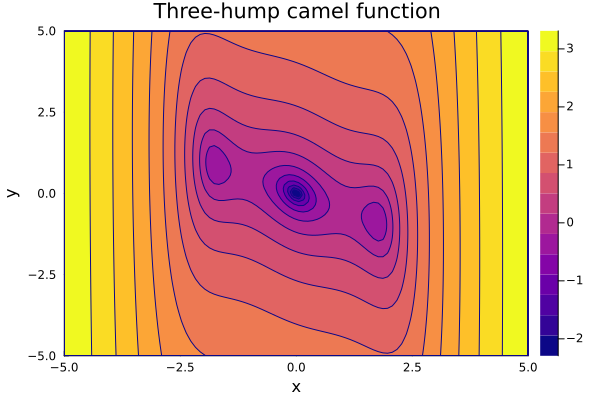

In [28]:
using LinearAlgebra
using Plots
using Random

# Wizualizacja funkcji
xs = range(DOMAIN[1], DOMAIN[2], length=100)
ys = range(DOMAIN[1], DOMAIN[2], length=100)
zs = [f([x, y]) for y in ys, x in xs]
zs_log = log10.(abs.(zs) .+ eps())   # logarytm dla czytelności

contourf(xs, ys, zs_log, color=:plasma, title="Three-hump camel function", xlabel="x", ylabel="y")

In [29]:
# zapisywanie historii punktów
function optimize_with_history(cost, grad!, x0; step=0.01, maxiter=100, tol=1e-6, optimization_function=my_optimize_const_step)
    x = copy(x0)
    history = Float64[]
    for k in 1:maxiter
        push!(history, cost(x))
        x = optimization_function(cost, grad!, x; step=step, maxiter=1, tol=tol)
    end
    push!(history, cost(x))
    return x, history
end

# Losowanie 10 punktów z dziedziny DOMAIN × DOMAIN
Random.seed!(42)
function rand_uniform(a, b)
    return [rand() * (b - a) + a, rand() * (b - a) + a]
end

starting_points = [rand_uniform(DOMAIN[1], DOMAIN[2]) for _ in 1:10]
println("Wylosowane punkty startowe:")
for (i, p) in enumerate(starting_points)
    println("  $i: x = $(round.(p, digits=2))")
end

Wylosowane punkty startowe:
  1: x = [1.29, -0.5]
  2: x = [-0.23, 2.03]
  3: x = [1.73, -3.34]
  4: x = [1.13, 1.68]
  5: x = [-0.43, -2.01]
  6: x = [1.61, 1.39]
  7: x = [-1.57, -2.32]
  8: x = [0.16, -4.1]
  9: x = [-2.27, -3.08]
  10: x = [-0.76, -0.15]


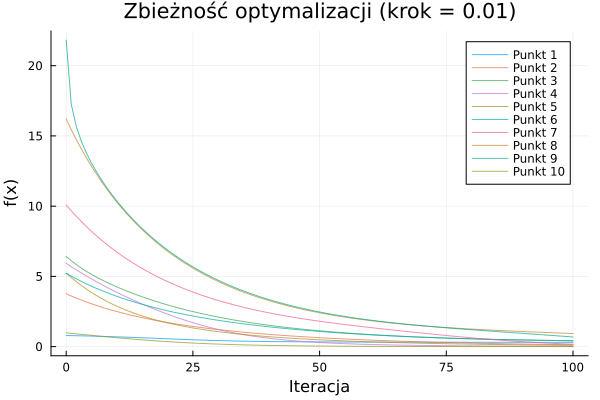

In [30]:
# 100 kroków optymalizacji dla każdego punktu, stały krok = 0.01
step_size = 0.01
all_histories = []

for x0 in starting_points
    _, hist = optimize_with_history(f, grad_f!, x0, step=step_size, maxiter=100)
    push!(all_histories, hist)
end

# Wykres
p = plot(title="Zbieżność optymalizacji (krok = $step_size)", 
         xlabel="Iteracja", ylabel="f(x)", legend=:topright)
for (i, hist) in enumerate(all_histories)
    plot!(p, 0:100, hist, label="Punkt $i", alpha=0.7)
end
display(p)

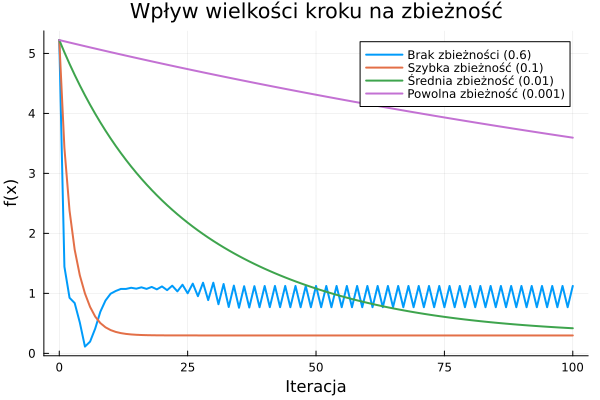

In [31]:
# Porównanie różnych kroków dla jednego punktu

step_sizes = [0.6, 0.1, 0.01, 0.001]  # różne kroki
labels = ["Brak zbieżności (0.6)", "Szybka zbieżność (0.1)", 
          "Średnia zbieżność (0.01)", "Powolna zbieżność (0.001)"]

          
test_point = starting_points[6]

p2 = plot(title="Wpływ wielkości kroku na zbieżność", 
          xlabel="Iteracja", ylabel="f(x)", legend=:topright)

for (step, label) in zip(step_sizes, labels)
    _, hist = optimize_with_history(f, grad_f!, test_point, step=step, maxiter=100)
    hist_clipped = clamp.(hist, -1e6, 1e6)
    plot!(p2, 0:100, hist_clipped, label=label, linewidth=2)
end
display(p2)

## Wnioski

**Analiza wpływu wielkości kroku:**

- **Krok = 0.5** - Zbyt duży krok powoduje brak zbieżności lub oscylacje. Algorytm "przeskakuje" minimum.
- **Krok = 0.1** - Odpowiedni krok dla szybkiej zbieżności do minimum.
- **Krok = 0.01** - Średnia zbieżność, bezpieczny wybór.
- **Krok = 0.001** - Zbyt mały krok, powolna zbieżność, algorytm wymaga wielu iteracji.


# Zadania na 4.0:

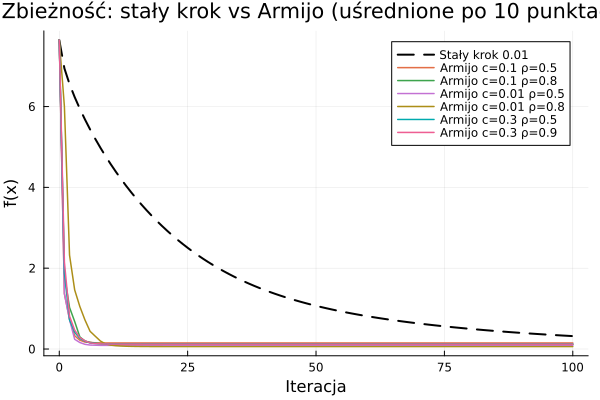

In [32]:
# Przeszukiwanie liniowe z warunkiem Armijo (backtracking)
# Bracket: [0, 1] → startujemy od alpha=1 i zmniejszamy
function armijo_line_search(cost, x, g; c=0.1, rho=0.5)
    d = -g                      # kierunek najstromszego spadku
    fx = cost(x)
    slope = dot(g, d)           # = -||g||² (zawsze < 0)
    alpha = 1.0                 # górny koniec bracketu [0, 1]

    while true
        if isfinite(cost(x .+ alpha .* d)) && cost(x .+ alpha .* d) <= fx + c * alpha * slope
            break
        end
        alpha *= rho
        alpha < 1e-16 && break
    end
    return alpha
end

# Optymalizacja metodą Armijo – taki sam interfejs jak my_optimize_const_step
function optimize_armijo_step(cost_data, grad_data, x0;
        step=nothing, maxiter=100, tol=1e-6, c=0.1, rho=0.5)

    x = copy(x0)
    g = similar(x)

    fx = cost_data(x)
    if !isfinite(fx)
        error("cost_data(x0) is not finite (got $fx).")
    end

    for k in 1:maxiter
        grad_data(g, x)
        any(!isfinite, g) && error("Gradient became non-finite at iter=$k")
        norm(g) < tol && return x
        alpha = armijo_line_search(cost_data, x, g; c=c, rho=rho)
        x .= x .- alpha .* g
    end
    return x
end

# Opakowanie zapisujące historię (analogiczne do optimize_with_history)
function optimize_armijo_with_history(cost, grad!, x0; maxiter=100, tol=1e-6, c=0.1, rho=0.5)
    x = copy(x0)
    history = Float64[]
    for k in 1:maxiter
        push!(history, cost(x))
        x = optimize_armijo_step(cost, grad!, x; maxiter=1, tol=tol, c=c, rho=rho)
    end
    push!(history, cost(x))
    return x, history
end

# ── Porównanie 6 kombinacji parametrów Armijo vs stały krok ──────────────────
armijo_configs = [
    (c=0.1,  rho=0.5,  label="Armijo c=0.1 ρ=0.5"),
    (c=0.1,  rho=0.8,  label="Armijo c=0.1 ρ=0.8"),
    (c=0.01, rho=0.5,  label="Armijo c=0.01 ρ=0.5"),
    (c=0.01, rho=0.8,  label="Armijo c=0.01 ρ=0.8"),
    (c=0.3,  rho=0.5,  label="Armijo c=0.3 ρ=0.5"),
    (c=0.3,  rho=0.9,  label="Armijo c=0.3 ρ=0.9"),
]

MAXITER = 100

# Uśrednione wartości funkcji po MAXITER krokach dla każdego punktu startowego
function mean_history(histories)
    return [mean(h[k] for h in histories) for k in 1:(MAXITER+1)]
end

using Statistics

# Stały krok (referencja)
fixed_histories = [optimize_with_history(f, grad_f!, x0; step=0.01, maxiter=MAXITER) |> last
                   for x0 in starting_points]
fixed_mean = mean_history(fixed_histories)

p3 = plot(0:MAXITER, fixed_mean, label="Stały krok 0.01", linewidth=2,
          linestyle=:dash, color=:black,
          title="Zbieżność: stały krok vs Armijo (uśrednione po 10 punktach)",
          xlabel="Iteracja", ylabel="f̄(x)")

for cfg in armijo_configs
    arm_histories = [optimize_armijo_with_history(f, grad_f!, x0;
                         maxiter=MAXITER, c=cfg.c, rho=cfg.rho) |> last
                     for x0 in starting_points]
    arm_mean = mean_history(arm_histories)
    plot!(p3, 0:MAXITER, arm_mean, label=cfg.label, linewidth=1.5)
end

display(p3)

# Zadania na 5.0:

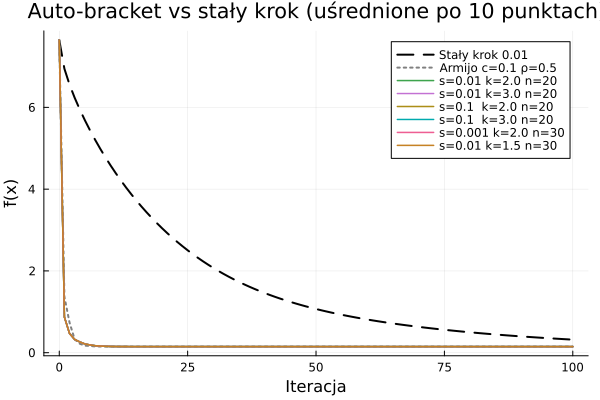

In [33]:

# bracket_minimum z wykładu (bez wykresów – używamy algorytmicznie)
function bracket_minimum(f, x=0.0; s=1e-2, k=2.0, n=20)
    a, ya = x, f(x)
    b, yb = a + s, f(a + s)
    if yb > ya
        a, b = b, a
        ya, yb = yb, ya
        s = -s
    end
    for i in 1:n
        c, yc = b + s, f(b + s)
        if yc > yb
            return a < c ? (a, c) : (c, a)
        end
        a, ya, b, yb = b, yb, c, yc
        s *= k
    end
    return (NaN, NaN)
end

# Złoty podział w przedziale [a, b]
function golden_section_search(f, a, b; tol=1e-8, maxiter=200)
    phi = (sqrt(5.0) - 1.0) / 2.0
    c = b - phi * (b - a)
    d = a + phi * (b - a)
    for _ in 1:maxiter
        abs(b - a) < tol && break
        if f(c) < f(d)
            b = d
        else
            a = c
        end
        c = b - phi * (b - a)
        d = a + phi * (b - a)
    end
    return (a + b) / 2.0
end

# Przeszukiwanie liniowe: auto-bracket + złoty podział
function bracket_line_search(cost, x, g; s=1e-2, k=2.0, n=20)
    d = -g
    phi_1d(alpha) = cost(x .+ alpha .* d)
    a_br, b_br = bracket_minimum(phi_1d, 0.0; s=s, k=k, n=n)
    if isnan(a_br)
        return 0.0
    end
    a_br = max(a_br, 0.0)
    return golden_section_search(phi_1d, a_br, b_br)
end

# Optymalizacja z auto-bracketingiem
function optimize_bracket_step(cost_data, grad_data, x0;
        step=nothing, maxiter=100, tol=1e-6, s=1e-2, k=2.0, n=20)
    x = copy(x0)
    g = similar(x)
    !isfinite(cost_data(x)) && error("cost_data(x0) is not finite.")
    for _ in 1:maxiter
        grad_data(g, x)
        any(!isfinite, g) && error("Gradient became non-finite")
        norm(g) < tol && return x
        alpha = bracket_line_search(cost_data, x, g; s=s, k=k, n=n)
        x .= x .- alpha .* g
    end
    return x
end

function optimize_bracket_with_history(cost, grad!, x0; maxiter=100, tol=1e-6, s=1e-2, k=2.0, n=20)
    x = copy(x0)
    history = Float64[]
    for _ in 1:maxiter
        push!(history, cost(x))
        x = optimize_bracket_step(cost, grad!, x; maxiter=1, tol=tol, s=s, k=k, n=n)
    end
    push!(history, cost(x))
    return x, history
end

# 6 zestawów parametrów bracketingu
bracket_configs = [
    (s=1e-2, k=2.0, n=20, label="s=0.01 k=2.0 n=20"),
    (s=1e-2, k=3.0, n=20, label="s=0.01 k=3.0 n=20"),
    (s=1e-1, k=2.0, n=20, label="s=0.1  k=2.0 n=20"),
    (s=1e-1, k=3.0, n=20, label="s=0.1  k=3.0 n=20"),
    (s=1e-3, k=2.0, n=30, label="s=0.001 k=2.0 n=30"),
    (s=1e-2, k=1.5, n=30, label="s=0.01 k=1.5 n=30"),
]

p4 = plot(0:MAXITER, fixed_mean, label="Stały krok 0.01", linewidth=2,
          linestyle=:dash, color=:black,
          title="Auto-bracket vs stały krok (uśrednione po 10 punktach)",
          xlabel="Iteracja", ylabel="f̄(x)")

arm_ref_histories = [optimize_armijo_with_history(f, grad_f!, x0; maxiter=MAXITER, c=0.1, rho=0.5) |> last
                     for x0 in starting_points]
plot!(p4, 0:MAXITER, mean_history(arm_ref_histories),
      label="Armijo c=0.1 ρ=0.5", linewidth=2, linestyle=:dot, color=:gray)

for cfg in bracket_configs
    br_histories = [optimize_bracket_with_history(f, grad_f!, x0;
                        maxiter=MAXITER, s=cfg.s, k=cfg.k, n=cfg.n) |> last
                    for x0 in starting_points]
    plot!(p4, 0:MAXITER, mean_history(br_histories), label=cfg.label, linewidth=1.5)
end

display(p4)
